In [1]:
%load_ext autoreload 
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import nibabel as nib
import os 
opj = os.path.join
%matplotlib inline 
sub = 'sub-01'




In [8]:
import os
opj = os.path.join
moco_folder = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/spm_align/sub-01'
rfiles_ = os.listdir(
    moco_folder
)
rfiles = [opj(moco_folder,f) for f in rfiles_ if f.startswith('rrun')]
rnib = [nib.load(f) for f in rfiles]
rdata = []
for i in range(len(rnib)):
    rdata.append(rnib[i].get_fdata())

In [2]:
dm_file = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/logfiles/col_dm_cond.mat'
tdm_mat = sio.loadmat(dm_file)
tn_trs = 90 # 90 timepts
t_tr = 3 #
dur = 30

In [66]:

dm_conds = [str(i[0]) for i in tdm_mat['names'][0]]
ons = {}
dur = {}
cond_list = []
for iC,c in enumerate(dm_conds):
    ons[c] = tdm_mat['onsets'][0][iC][0] # weird matlab... have to index this way
    if c != 'rest':
        cond_list.append(c)
print(ons['rest'])
print(ons['colour'])
print(ons['bw'])

conditions = ['col', 'bw', 'bw', 'col', 'col', 'bw', 'bw', 'col']
duration =   [30] * len(conditions)
onsets = [15, 45, 75, 105, 135, 165, 195, 225, ]

[8.45125000e-04 2.55008815e+02]
[ 15.01033804 105.00170842 135.01069308 225.01644929]
[ 45.00162958  75.01012975 165.00254796 195.00816542]


In [67]:
# https://nilearn.github.io/dev/auto_examples/04_glm_first_level/plot_design_matrix.html#sphx-glr-auto-examples-04-glm-first-level-plot-design-matrix-py
from nilearn.plotting import plot_design_matrix
t_r = 3
n_scans = 90
frame_times = (np.arange(n_scans) * t_r) # Corresponding frame times

# Next, we simulate 6 motion parameters jointly observed with fMRI acquisitions
# rng = np.random.default_rng(42)
# motion = np.cumsum(rng.standard_normal((n_scans, 6)), 0)
# # The 6 parameters correspond to three translations and three
# # rotations describing rigid body motion
# add_reg_names = ["tx", "ty", "tz", "rx", "ry", "rz"]

<Axes: label='conditions', ylabel='scan number'>

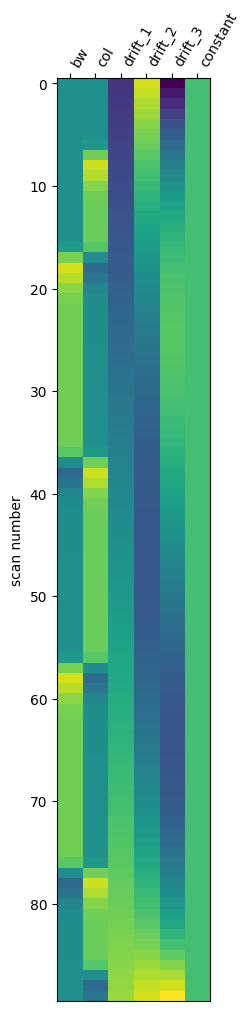

In [68]:
import pandas as pd

events = pd.DataFrame(
    {"trial_type": conditions, "onset": onsets, "duration": duration}
)


from nilearn.glm.first_level import make_first_level_design_matrix

hrf_model = "glover"
X1 = make_first_level_design_matrix(
    frame_times,
    events,
    drift_model="polynomial",
    drift_order=3,
    # add_regs=motion,
    # add_reg_names=add_reg_names,
    hrf_model=hrf_model,
)
plot_design_matrix(X1)

In [40]:
X1

,bw,col,drift_1,drift_2,drift_3,constant
0,0.000000,0.000000,-0.500000,0.164794,-0.048327,1.0
3,0.000000,0.000000,-0.488764,0.153684,-0.041811,1.0
6,0.000000,0.000000,-0.477528,0.142827,-0.035665,1.0
9,0.000000,0.000000,-0.466292,0.132222,-0.029881,1.0
12,0.000000,0.000000,-0.455056,0.121870,-0.024450,1.0
...,...,...,...,...,...,...
255,-0.000019,1.000019,0.455056,0.121870,0.024450,1.0
258,0.000000,0.867644,0.466292,0.132222,0.029881,1.0
261,0.000000,-0.042306,0.477528,0.142827,0.035665,1.0
264,0.000000,-0.551156,0.488764,0.153684,0.041811,1.0


In [43]:
# https://nilearn.github.io/dev/auto_examples/04_glm_first_level/plot_write_events_file.html#sphx-glr-auto-examples-04-glm-first-level-plot-write-events-file-py

fmri_glms = []
for i in range(3):
    subject_data = rfiles[i]
    from nilearn.glm.first_level import FirstLevelModel
    tglm = FirstLevelModel()
    fmri_glms.append(
        tglm.fit(subject_data, design_matrices=X1)
    )

In [65]:
tcont = []
for i in range(3):
    tcont.append(
        fmri_glms[i].compute_contrast('col > bw').get_fdata())
tcont_mean = np.mean(tcont, axis=0)
# Save as nib
reference_img = fmri_glms[0].compute_contrast('bw > 0') 

new_img = nib.Nifti1Image(
    tcont_mean.astype(np.float32), 
    reference_img.affine, 
    header=reference_img.header # Adding the header is key
)
nib.save(new_img, 'avgcolmbw10.nii')

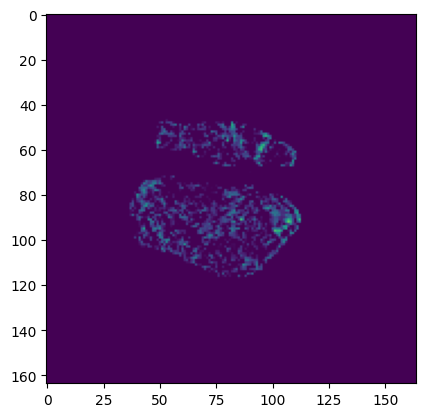

In [52]:
plt.imshow(
    tcont[:,:,-10], 
    vmin=0, vmax=5
)

In [42]:
a = fmri_glm.compute_contrast('bw > 0')
nib.save(a, 'contbwm0.nii')

In [261]:
tdm_mat['onsets'][0][2] 

array([[ 15.01033804, 105.00170842, 135.01069308, 225.01644929]])

In [310]:
import os
opj = os.path.join
moco_folder = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/spm_align/sub-01'
rfiles_ = os.listdir(
    moco_folder
)
rfiles = [opj(moco_folder,f) for f in rfiles_ if f.startswith('rrun')]
rnib = [nib.load(f) for f in rfiles]
rdata = []
for i in range(len(rnib)):
    rdata.append(rnib[i].get_fdata())
# run1_file = 
# r1 = nib.load(run1_file)
# tfunc = r1.get_fdata()

In [311]:
len(rdata)

3

In [150]:
# plt.imshow(tfunc[:,:,-20,0])
# tfsl = tfunc[:,:,-21:-20,:].copy()

In [312]:
import glmsingle
from glmsingle.glmsingle import GLM_single
import scipy
import os
import shutil
opj = os.path.join
# create a directory for saving GLMsingle outputs
deriv_dir = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives'
outputdir_glmsingle = opj(deriv_dir, 'glmsingle', sub, 'test830snohrf')
if not os.path.exists(outputdir_glmsingle):
    os.makedirs(outputdir_glmsingle)
else:
    shutil.rmtree(outputdir_glmsingle)
    os.makedirs(outputdir_glmsingle)

opt = dict()

# set important fields for completeness (but these would be enabled by default)
opt['wantlibrary'] = 0
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 0

# for the purpose of this example we will keep the relevant outputs in memory
# and also save them to the disk
opt['wantfileoutputs'] = [1,1,1,1]
opt['wantmemoryoutputs'] = [1,1,1,1]

# running python GLMsingle involves creating a GLM_single object
# and then running the procedure using the .fit() routine
glmsingle_obj = GLM_single(opt)

# visualize all the hyperparameter

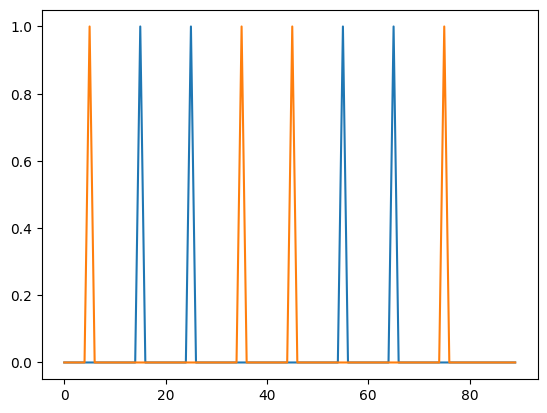

In [269]:
plt.plot(t_dmatrix_info['dmatrix'])
dm1id = np.array([0,3,4,7])
dm2id = np.array([1,2,5,6])

In [313]:
# variables that will contain bold time-series and design matrices from each run
data = []
design = []

nruns = 0
for R in range(len(rdata)):
    data.append(
        rdata[R],
        # tfunc #[:,:,20:21,:]
        )
    design.append(t_dmatrix_info['dmatrix'])
    nruns += 1

# get shape of data volume (XYZ) for convenience
xyz = data[0].shape[:3]
xyzt = data[0].shape

# get total number of blocks - this will be the dimensionality of output betas from GLMsingle
nblocks = int(np.sum(np.concatenate(design)))

# get metadata about stimulus duration and TR
stimdur = 30 # hmm t_dmatrix_info['dur']['bw']
tr = 3.0

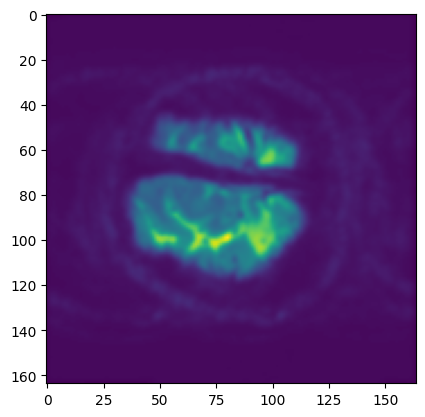

In [301]:
plt.imshow(data[0][:,:,-10,0])

In [297]:
plt.imshow(data[0][:,:,-10,10]) #- data[1][:,:,0,1])

IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed

In [314]:
# run GLMsingle
results_glmsingle = glmsingle_obj.fit(
   design,
   data,
   stimdur,
   tr,
   outputdir=outputdir_glmsingle)

*** DIAGNOSTICS ***:
There are 3 runs.
The number of conditions in this experiment is 2.
The stimulus duration corresponding to each trial is 30.00 seconds.
The TR (time between successive data points) is 3.00 seconds.
The number of trials in each run is: [8, 8, 8].
The number of trials for each condition is: [np.int64(12), np.int64(12)].
For each condition, the number of runs in which it appears: [np.int64(3), np.int64(3)].
For each run, how much ending buffer do we have in seconds? [np.float64(42.0), np.float64(42.0), np.float64(42.0)].
*** Saving design-related results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-01/test830snohrf/DESIGNINFO.npy. ***
*** FITTING DIAGNOSTIC RUN-WISE FIR MODEL ***
*** Saving FIR results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-01/test830snohrf/RUNWISEFIR.npy. ***

*** FITTING TYPE-A MODEL (ONOFF) ***

fitting model...
done.

preparing output...
done.

comp

/Users/marcusdaghlian/miniforge3/envs/glms001/lib/python3.14/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


*** Setting brain R2 threshold to 0.5259465739237177 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



chunks: 100%|██████████| 24/24 [00:06<00:00,  3.73it/s]



*** Saving results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-01/test830snohrf/TYPEB_FITHRF.npy. ***

*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 24/24 [00:52<00:00,  2.19s/it]



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 24/24 [00:17<00:00,  1.36it/s]


*** Saving results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-01/test830snohrf/TYPEC_FITHRF_GLMDENOISE.npy. ***

*** All model types done ***

*** return model types in results ***



In [315]:
# Get m
meanvol = np.squeeze(np.mean(data[0].reshape(xyzt),3))
r2_th = results_glmsingle['typeb']['R2']>20
brainmask = meanvol > 2500
beta_id = {
    'bw' : [0,3,4,7],
    'col':[1,2,5,6],
}
betas = {}
for k in beta_id.keys():
    betas[k] = []
    for i in beta_id[k]:
        betas[k].append(results_glmsingle['typec']['betasmd'][:,:,:,i])
    betas[k] = np.mean(betas[k], axis=0)

bth = betas.copy()
for k in bth.keys():
    
    bth[k][~brainmask] = np.nan
    bth[k][~r2_th] = np.nan


In [322]:
ball=(bth['col']+bth['bw'])/2
ball=results_glmsingle['typea']['onoffR2']
ball

array([[[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan, 1.00662245e-01, 2.17699017e-01, ...,
                    nan,            nan,            nan],
        [           nan, 2.01462661e-01, 1.15008030e-01, ...,
                    nan,            nan,            nan],
        [           nan, 

In [247]:
np.nanmax(results_glmsingle['typeb']['R2'])

np.float32(45.367443)

In [323]:
# ball = results_glmsingle['typeb']['R2']
ball_img = nib.Nifti1Image(ball.astype(np.float32), rnib[0].affine)
nib.save(ball_img, 'blahonoff.nii')


# nilearn denoising

In [9]:
from nilearn.interfaces.fmriprep import load_confounds_strategy
from nilearn.maskers import NiftiMasker
import os
opj = os.path.join
# 1. Define paths to your fMRIPrep outputs
fmriprep_path = '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/BIDS/derivatives/fmriprep/sub-01/ses-1/func'
bold_files_ = os.listdir(fmriprep_path)
bold_files = [opj(fmriprep_path,b) for b in bold_files_ if 'preproc_bold.nii' in b]
img_paths = bold_files

In [10]:




# 2. Load PCA-based confounds (CompCor)
# This selects 5 anatomical CompCor components (PCA) + motion parameters
confounds, sample_mask = load_confounds_strategy(
    img_paths, 
    denoise_strategy="compcor", 
    n_compcor=5
)


In [ ]:

# 3. Apply denoising using a Masker
masker = NiftiMasker(
    standardize=True, 
    smoothing_fwhm=0, 
    detrend=True, 
    low_pass=0.08, 
    high_pass=0.01, 
    t_r=3.0
)

# This step performs the actual regression of the PCA components
denoised_data = masker.fit_transform(img_paths, confounds=confounds, sample_mask=sample_mask)


In [ ]:

# (Optional) Reconstruct into a 4D Nifti if needed
denoised_img = masker.inverse_transform(denoised_data)
denoised_img.to_filename('sub-01_denoised_PCA.nii.gz')